17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (25000, 200)
Testing shape: (25000, 200)

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,737 (5.07 MB)

 Trainable params: 1,329,737 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7988 - loss: 0.4151 - val_accuracy: 0.8734 - val_loss: 0.3093
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9092 - loss: 0.2304 - val_accuracy: 0.8728 - val_loss: 0.3059
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9371 - loss: 0.1668 - val_accuracy: 0.8654 - val_loss: 0.3536
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9625 - loss: 0.1063 - val_accuracy: 0.8650 - val_loss: 0.3499
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9764 - loss: 0.0698 - val_accuracy: 0.8628 - val_loss: 0.4695


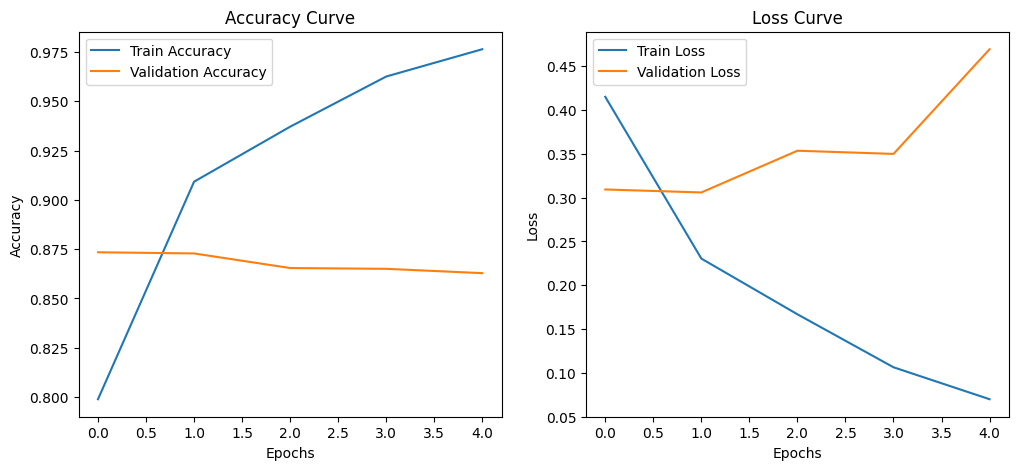

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8466 - loss: 0.5250

Test Accuracy: 0.8466399908065796
Test Loss: 0.5250083804130554
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


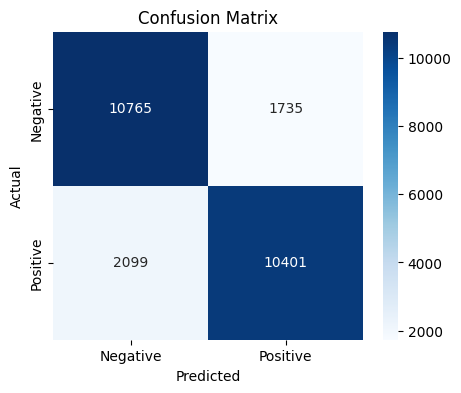


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85     12500
           1       0.86      0.83      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



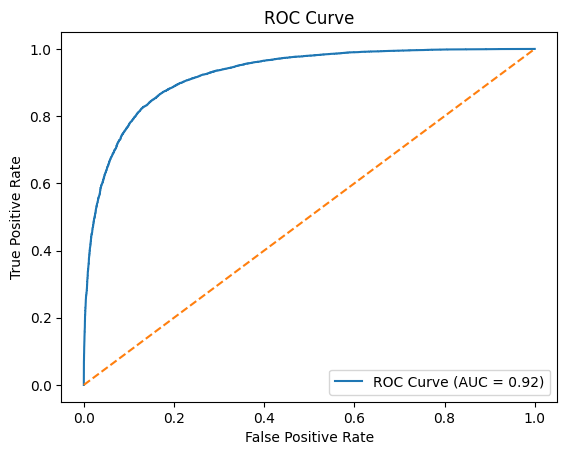


Sample Predictions with Interpretation

Review 1
Actual : Negative
Predicted : Negative
Confidence : 0.006
----------------------------------------
Review 2
Actual : Positive
Predicted : Positive
Confidence : 1.0
----------------------------------------
Review 3
Actual : Positive
Predicted : Negative
Confidence : 0.282
----------------------------------------
Review 4
Actual : Negative
Predicted : Negative
Confidence : 0.4
----------------------------------------
Review 5
Actual : Positive
Predicted : Positive
Confidence : 1.0
----------------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
# -----------------------------------------------------------
# Step 2: Load Dataset
# -----------------------------------------------------------
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
# -----------------------------------------------------------
# Step 3: Attention Layer
# -----------------------------------------------------------
class Attention(Layer):
  def build(self, input_shape):
    self.W = self.add_weight(shape=(input_shape[-1], 1),
    initializer='normal',
    trainable=True)
    self.b = self.add_weight(shape=(input_shape[1], 1),
    initializer='zeros',
    trainable=True)
  def call(self, x):
    e = tf.tanh(tf.matmul(x, self.W) + self.b)
    a = tf.nn.softmax(e, axis=1)
    context = x * a
    context = tf.reduce_sum(context, axis=1)
    return context
# -----------------------------------------------------------
# Step 4: Build Model
# -----------------------------------------------------------
inputs = Input(shape=(max_len,))
x = Embedding(vocab_size, 128)(inputs)
x = LSTM(64, return_sequences=True)(x)
x = Attention()(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
print("\nModel Summary:")
model.summary()
# -----------------------------------------------------------
# Step 5: Train Model
# -----------------------------------------------------------
history = model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)
# -----------------------------------------------------------
# Step 6: Plot Training Curves
# -----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
# -----------------------------------------------------------
# Step 7: Model Evaluation
# -----------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)
# -----------------------------------------------------------
# Step 8: Predictions (Inference)
# -----------------------------------------------------------
predictions = model.predict(X_test)
# Convert probabilities to class labels
y_pred = (predictions > 0.5).astype(int)
# -----------------------------------------------------------
# Step 9: Confusion Matrix
# -----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
xticklabels=["Negative","Positive"],
yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# -----------------------------------------------------------
# Step 10: Classification Report
# -----------------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# -----------------------------------------------------------
# Step 11: ROC Curve and AUC
# -----------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
# -----------------------------------------------------------
# Step 12: Interpretation of Predictions
# -----------------------------------------------------------
print("\nSample Predictions with Interpretation\n")
for i in range(5):
  prob = predictions[i][0]
  predicted = "Positive" if prob > 0.5 else "Negative"
  actual = "Positive" if y_test[i] == 1 else "Negative"
  print(f"Review {i+1}")
  print("Actual :", actual)
  print("Predicted :", predicted)
  print("Confidence :", round(prob,3))
  print("-"*40)